# Validation 2: Score–affinity correlation

Spearman rank correlation between Rosetta summary scores (`rosetta_best_score`, `rosetta_mean_score`) and experimental log-affinity (IC50, Kd). Reports per-allele and pooled correlations.

Censored values at the assay detection limits are excluded.

Outputs: `correlations_per_allele.csv`, `correlations_pooled.json`, `figure3_score_vs_affinity.{png,pdf}` in `IEDB_validation/02_score_affinity/`.

Reads only `metadata.csv`; does not touch structure files.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
from utils import load_metadata, set_plot_style

set_plot_style()

In [2]:
# === Paths ===
from paths import DATA_ROOT, MHC_DB_ROOT, CLUSTER_ROOT  # roots; override with PEPBIND3D_* env vars
HF_DIR     = DATA_ROOT / "huggingface"
SCORES_DIR = DATA_ROOT / "IEDB_validation/scores_out"
OUT_DIR    = DATA_ROOT / "IEDB_validation/02_score_affinity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG3_DIR = DATA_ROOT / "IEDB_validation/figure3_panels"
FIG3_DIR.mkdir(parents=True, exist_ok=True)

# === Column names ===
COL_ALLELE  = 'allele'
COL_PEPTIDE = 'peptide'
COL_FLAGGED = 'flagged'

# === Score metrics ===
# I_sc (interface score) is primary: it isolates the peptide-MHC interaction
# energy, whereas total_score is dominated by the invariant internal energy
# of the MHC receptor. reweighted_sc is reported alongside because it was
# used in prior applications of this pipeline (Bloodworth 2022, Patrick 2024).
PRIMARY_METRIC = 'I_sc'
METRICS        = ['I_sc', 'reweighted_sc', 'total_score', 'pep_sc']
SCORE_COLS     = {m: (f'{m}_best', f'{m}_mean') for m in METRICS}

# === Censoring ===
# Values equal to a recurrent assay ceiling, or at/above the highest ceiling,
# are non-quantitative and excluded. Thresholds chosen from the empirical
# value_counts spikes; see censoring_sensitivity.csv for the sensitivity analysis.
IC50_CEILINGS = (20000.0, 50000.0, 70000.0)
KD_CEILINGS   = (5000.0, 10000.0, 20000.0)
IC50_FLOOR    = 70000.0   # drop everything >= this
KD_FLOOR      = 20000.0

## Load and filter

In [3]:
df = load_metadata(HF_DIR / 'metadata.csv')
df = df[~df[COL_FLAGGED].astype(bool)].copy()

def allele_to_dir(a):
    s = a[4:] if a.startswith('HLA-') else a
    return s.replace('*', '').replace(':', '')

df['allele_dir'] = df[COL_ALLELE].map(allele_to_dir)

# Scores come from metadata.csv itself, written by release/add_release_columns.py.
# Do NOT merge scores_out/score_summary.csv here. That file is the v1-only
# summary (49,268 pairs against 112,561) and it predates the re-dock of the
# 1,162 content-defective pairs, so merging it would drop the v2 batch and
# restore the old scores for those 1,162: median I_sc_best -11.60 REU, against
# -68.57 REU after the re-dock.
missing = [col for m in METRICS for col in (f'{m}_best', f'{m}_mean')
           if col not in df.columns]
assert not missing, (f'metadata.csv lacks {missing}. Regenerate it with '
                     'release/add_release_columns.py.')

for m in METRICS:
    n_missing = df[f'{m}_best'].isna().sum()
    print(f'{m}: {n_missing:,} rows without a score ({n_missing/len(df)*100:.2f}%)')
print(f'{len(df):,} rows, {df.groupby([COL_ALLELE, COL_PEPTIDE]).ngroups:,} pairs')


I_sc: 0 rows without a score (0.00%)
reweighted_sc: 0 rows without a score (0.00%)
total_score: 0 rows without a score (0.00%)
pep_sc: 0 rows without a score (0.00%)
118,970 rows, 112,546 pairs


In [4]:
# === Column schema ===
COL_MEAS_TYPE  = 'measurement_type'
COL_MEAS_VALUE = 'measurement_value'
COL_MEAS_UNITS = 'measurement_units'

# Quick sanity check on units (we assume nM throughout)
unit_counts = df[COL_MEAS_UNITS].value_counts()
print('Measurement units:')
print(unit_counts)
if not (unit_counts.index == 'nM').all():
    print('WARNING: non-nM units present; review before proceeding.')

def is_censored(values: pd.Series, ceilings: tuple, floor: float) -> pd.Series:
    """Censored if equal to a recurrent ceiling value or at/above the cutoff."""
    return values.isin(ceilings) | (values >= floor)

# Split into IC50 and Kd subsets
score_cols = [c for m in METRICS for c in SCORE_COLS[m]]

def prep(sub, ceilings, floor, label):
    sub = sub[[COL_ALLELE, COL_MEAS_VALUE] + score_cols].copy()
    sub = sub.dropna(subset=[COL_MEAS_VALUE, f'{PRIMARY_METRIC}_best'])
    sub = sub[~is_censored(sub[COL_MEAS_VALUE], ceilings, floor)]
    sub['log_value'] = np.log10(sub[COL_MEAS_VALUE])
    sub['affinity_type'] = label
    return sub

ic50 = prep(df[df[COL_MEAS_TYPE] == 'IC50'], IC50_CEILINGS, IC50_FLOOR, 'IC50')
kd   = prep(df[df[COL_MEAS_TYPE] == 'Kd'],   KD_CEILINGS,   KD_FLOOR,   'Kd')

print(f'\nUsable IC50 pairs: {len(ic50):,}')
print(f'Usable Kd pairs:   {len(kd):,}')

print('\nIC50 value distribution (post-filter):')
print(ic50[COL_MEAS_VALUE].describe())
print('\nKd value distribution (post-filter):')
print(kd[COL_MEAS_VALUE].describe())

Measurement units:
measurement_units
nM    118970
Name: count, dtype: int64

Usable IC50 pairs: 18,113
Usable Kd pairs:   48,395

IC50 value distribution (post-filter):
count    18113.000000
mean      7830.857534
std      14468.369785
min          0.001700
25%         72.000000
50%        879.400000
75%       8059.400000
max      69924.810000
Name: measurement_value, dtype: float64

Kd value distribution (post-filter):
count    48395.000000
mean      2047.689470
std       3889.743412
min          0.000431
25%         25.900000
50%        245.000000
75%       1840.000000
max      19990.000000
Name: measurement_value, dtype: float64


## Pooled correlations

In [5]:
def spearman(x: np.ndarray, y: np.ndarray) -> dict:
    r = stats.spearmanr(x, y)
    return {'rho': float(r.statistic), 'pvalue': float(r.pvalue), 'n': int(len(x))}

pooled = {}
for assay, d in (('IC50', ic50), ('Kd', kd)):
    pooled[assay] = {}
    for m in METRICS:
        for agg, col in zip(('best', 'mean'), SCORE_COLS[m]):
            pooled[assay][f'{m}_{agg}'] = spearman(d[col], d['log_value'])

with open(OUT_DIR / 'correlations_pooled.json', 'w') as f:
    json.dump(pooled, f, indent=2)

print(pd.DataFrame({
    (a, m): {'rho': round(v['rho'], 3), 'p': f"{v['pvalue']:.2g}", 'n': v['n']}
    for a, mm in pooled.items() for m, v in mm.items()
}).T.to_string())

                           rho         p      n
IC50 I_sc_best           0.315         0  18113
     I_sc_mean            0.24    7e-236  18113
     reweighted_sc_best  0.126     3e-65  18113
     reweighted_sc_mean  0.033   7.8e-06  18113
     total_score_best    0.014     0.063  18113
     total_score_mean   -0.025    0.0009  18113
     pep_sc_best          0.14   1.7e-79  18113
     pep_sc_mean         0.043   6.6e-09  18113
Kd   I_sc_best           0.179         0  48395
     I_sc_mean           0.157  1.3e-265  48395
     reweighted_sc_best  0.119  2.6e-151  48395
     reweighted_sc_mean  0.069   2.1e-52  48395
     total_score_best    0.057   1.6e-35  48395
     total_score_mean    0.033   2.2e-13  48395
     pep_sc_best         0.114  6.5e-140  48395
     pep_sc_mean          0.08   6.6e-69  48395


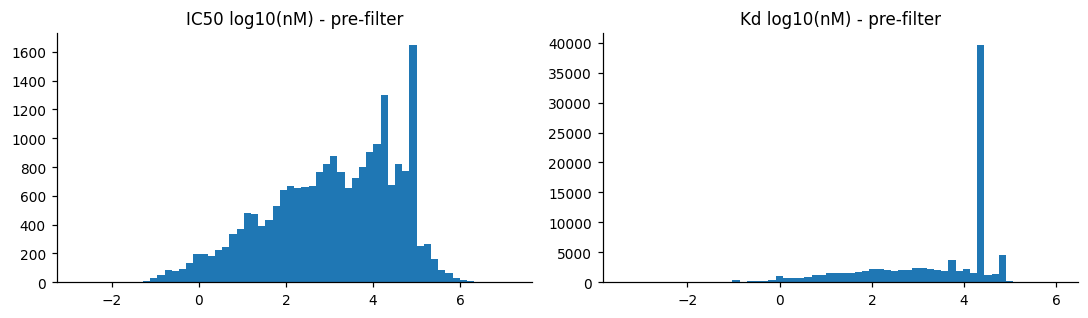

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(np.log10(df[df[COL_MEAS_TYPE]=='IC50'][COL_MEAS_VALUE].dropna()), bins=60)
axes[0].set_title('IC50 log10(nM) - pre-filter')
axes[1].hist(np.log10(df[df[COL_MEAS_TYPE]=='Kd'][COL_MEAS_VALUE].dropna()), bins=60)
axes[1].set_title('Kd log10(nM) - pre-filter')
plt.tight_layout()
plt.show()

## Per-allele correlations

In [7]:
def per_allele_corr(d: pd.DataFrame, score_col: str, label: str) -> pd.DataFrame:
    rows = []
    for allele, g in d.groupby(COL_ALLELE):
        if len(g) < 10:
            continue
        s = spearman(g[score_col], g['log_value'])
        rows.append({'allele': allele, 'metric': label, **s})
    return pd.DataFrame(rows)

per_allele = pd.concat([
    per_allele_corr(d, col, f'{m}_{agg}_vs_log_{assay.lower()}')
    for assay, d in (('IC50', ic50), ('Kd', kd))
    for m in METRICS
    for agg, col in zip(('best', 'mean'), SCORE_COLS[m])
], ignore_index=True)
per_allele.to_csv(OUT_DIR / 'correlations_per_allele.csv', index=False)

per_allele.head(10)

,allele,metric,rho,pvalue,n
0,A*01:01,I_sc_best_vs_log_ic50,0.306434,1.189758e-05,197
1,A*02:01,I_sc_best_vs_log_ic50,0.388810,1.639902e-191,5319
2,A*02:02,I_sc_best_vs_log_ic50,0.330600,1.901119e-61,2366
3,A*02:03,I_sc_best_vs_log_ic50,0.294902,7.935868e-49,2373
4,A*02:05,I_sc_best_vs_log_ic50,-0.083477,7.118811e-01,22
5,A*02:06,I_sc_best_vs_log_ic50,0.322792,4.653783e-56,2264
6,A*03:01,I_sc_best_vs_log_ic50,0.139546,4.032383e-03,423
7,A*11:01,I_sc_best_vs_log_ic50,0.173768,1.556038e-04,469
8,A*23:01,I_sc_best_vs_log_ic50,0.689502,3.515323e-05,29
9,A*24:02,I_sc_best_vs_log_ic50,0.351136,1.786592e-18,587


## Figure 3: Score vs log-affinity (pooled, hex density)

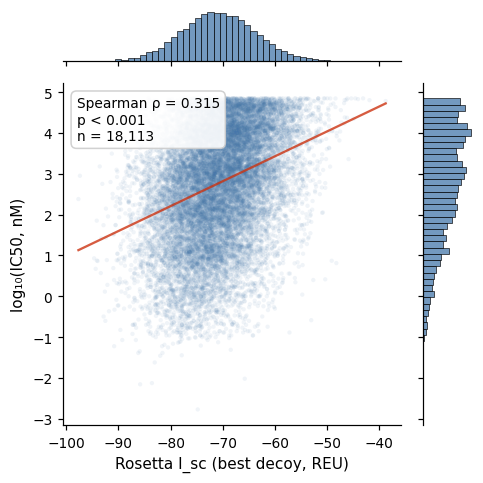

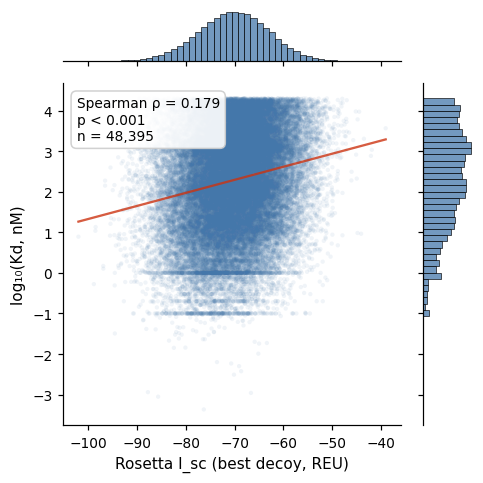

In [8]:
import seaborn as sns
from scipy.stats import linregress

SCORE_COL = f'{PRIMARY_METRIC}_best'
SCORE_LABEL = f'Rosetta {PRIMARY_METRIC} (best decoy, REU)'

lr_ic50 = linregress(ic50[SCORE_COL], ic50['log_value'])
lr_kd   = linregress(kd[SCORE_COL],   kd['log_value'])

def make_joint(data, ylabel, title, slope_intercept, rho_dict, out_name):
    g = sns.jointplot(
        data=data, x=SCORE_COL, y='log_value',
        kind='scatter',
        height=4.5,
        marginal_kws=dict(bins=50, fill=True, color='#4477AA'),
        joint_kws=dict(alpha=0.08, s=8, color='#4477AA', edgecolor='none'),
    )
    x = np.linspace(data[SCORE_COL].min(), data[SCORE_COL].max(), 100)
    g.ax_joint.plot(x, slope_intercept.slope * x + slope_intercept.intercept,
                    color='#CC3311', linewidth=1.5, alpha=0.8)
    g.ax_joint.set_xlabel(SCORE_LABEL)
    g.ax_joint.set_ylabel(ylabel)

    p_str = ('p < 0.001' if rho_dict['pvalue'] < 0.001
             else f"p = {rho_dict['pvalue']:.3f}")
    rho_disp = 0.0 if abs(rho_dict['rho']) < 5e-3 else rho_dict['rho']

    g.ax_joint.text(
        0.04, 0.96,
        f"Spearman ρ = {rho_disp:.3f}\n{p_str}\nn = {rho_dict['n']:,}",
        transform=g.ax_joint.transAxes,
        ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9))

    g.figure.tight_layout()
    g.figure.savefig(FIG3_DIR / f'{out_name}.png', dpi=300, bbox_inches='tight')
    g.figure.savefig(FIG3_DIR / f'{out_name}.pdf', bbox_inches='tight')
    return g

make_joint(ic50, 'log₁₀(IC50, nM)', 'IC50', lr_ic50,
           pooled['IC50'][f'{PRIMARY_METRIC}_best'],
           f'figure3a_ic50_vs_{PRIMARY_METRIC}')
make_joint(kd,   'log₁₀(Kd, nM)',   'Kd',   lr_kd,
           pooled['Kd'][f'{PRIMARY_METRIC}_best'],
           f'figure3b_kd_vs_{PRIMARY_METRIC}')
plt.show()

In [9]:
print('Pipeline counts:')
print(f'  Total metadata rows (post-flag-drop): {len(df):,}')

SCORE_COL = f'{PRIMARY_METRIC}_best'

for measurement_type, ceilings, floor in [
        ('IC50', IC50_CEILINGS, IC50_FLOOR),
        ('Kd',   KD_CEILINGS,   KD_FLOOR)]:
    sub = df[df[COL_MEAS_TYPE] == measurement_type].copy()
    n_total = len(sub)

    sub_nonnan = sub.dropna(subset=[COL_MEAS_VALUE, SCORE_COL])
    n_after_nan = len(sub_nonnan)

    censored = is_censored(sub_nonnan[COL_MEAS_VALUE], ceilings, floor)
    n_censored = int(censored.sum())
    n_after_censor = n_after_nan - n_censored

    print(f'\n  {measurement_type}:')
    print(f'    Rows of this measurement type:        {n_total:,}')
    print(f'    After dropping NaN score/value:       {n_after_nan:,}   (lost {n_total - n_after_nan:,})')
    print(f'    Of those, censored:                   {n_censored:,}   ({n_censored/n_after_nan*100:.1f}%)')
    print(f'    Usable (kept for correlation):        {n_after_censor:,}   ({n_after_censor/n_total*100:.1f}% of type total)')

Pipeline counts:
  Total metadata rows (post-flag-drop): 118,970

  IC50:
    Rows of this measurement type:        21,227
    After dropping NaN score/value:       21,227   (lost 0)
    Of those, censored:                   3,114   (14.7%)
    Usable (kept for correlation):        18,113   (85.3% of type total)

  Kd:
    Rows of this measurement type:        97,743
    After dropping NaN score/value:       97,743   (lost 0)
    Of those, censored:                   49,348   (50.5%)
    Usable (kept for correlation):        48,395   (49.5% of type total)


In [10]:
# What "round number" values appear suspiciously often? These are likely censoring values.
for measurement_type in ['IC50', 'Kd']:
    sub = df[df[COL_MEAS_TYPE] == measurement_type][COL_MEAS_VALUE]
    counts = sub.value_counts().head(10)
    print(f'\n{measurement_type}: top 10 most common values:')
    print(counts)


IC50: top 10 most common values:
measurement_value
70000.0     1088
20000.0      570
100000.0     172
12.0          97
11.0          96
50000.0       90
13.0          88
14.0          81
15.0          80
17.0          76
Name: count, dtype: int64

Kd: top 10 most common values:
measurement_value
20000.0    38279
5000.0      2087
70000.0      643
1.0          605
77700.0      400
77900.0      378
10000.0      331
78100.0      288
0.1          266
77500.0      220
Name: count, dtype: int64


## Per-allele correlation distribution

In [11]:
def summarize_per_allele(d: pd.DataFrame) -> dict:
    return {
        'n_alleles':           len(d),
        'median_rho':          d['rho'].median(),
        'iqr_rho':             (d['rho'].quantile(0.25), d['rho'].quantile(0.75)),
        'n_significant':       int((d['pvalue'] < 0.05).sum()),
        'pct_significant':     (d['pvalue'] < 0.05).mean() * 100,
        'n_rho_above_0.3':     int((d['rho'] > 0.3).sum()),
        'n_negative':          int((d['rho'] < 0).sum()),
    }

summary_rows = []
for label, group in per_allele.groupby('metric'):
    s = summarize_per_allele(group)
    summary_rows.append({'metric': label, **s})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'per_allele_summary.csv', index=False)
print(summary_df.to_string(index=False))

                        metric  n_alleles  median_rho                                      iqr_rho  n_significant  pct_significant  n_rho_above_0.3  n_negative
         I_sc_best_vs_log_ic50         35    0.207107   (0.10054229195845013, 0.36998673469524496)             20        57.142857               15           5
           I_sc_best_vs_log_kd         80    0.172044   (0.05379837150777995, 0.24171172579997552)             47        58.750000               12          13
         I_sc_mean_vs_log_ic50         35    0.208309     (0.0818682675843596, 0.3065817824537551)             19        54.285714               10           4
           I_sc_mean_vs_log_kd         80    0.142324   (0.05419033968748288, 0.23870695176005657)             44        55.000000                9          13
       pep_sc_best_vs_log_ic50         35    0.125000  (-0.05481442839929426, 0.19063908423104522)             12        34.285714                4          11
         pep_sc_best_vs_log_kd         8

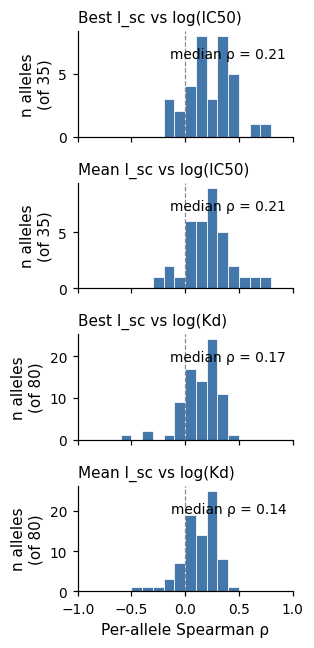

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(3, 6), sharex=True)
metrics = [f'{PRIMARY_METRIC}_best_vs_log_ic50',
           f'{PRIMARY_METRIC}_mean_vs_log_ic50',
           f'{PRIMARY_METRIC}_best_vs_log_kd',
           f'{PRIMARY_METRIC}_mean_vs_log_kd']
titles  = [f'Best {PRIMARY_METRIC} vs log(IC50)',
           f'Mean {PRIMARY_METRIC} vs log(IC50)',
           f'Best {PRIMARY_METRIC} vs log(Kd)',
           f'Mean {PRIMARY_METRIC} vs log(Kd)']

for ax, metric, title in zip(axes, metrics, titles):
    sub = per_allele[per_allele['metric'] == metric]
    ax.hist(sub['rho'], bins=np.arange(-1, 1.05, 0.1), color='#4477AA',
            edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#888888', linewidth=0.8, linestyle='--')
    ax.set_ylabel(f'n alleles\n(of {len(sub)})')
    ax.text(0.97, 0.85,
            f'median ρ = {sub["rho"].median():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9)
    ax.set_title(title, fontsize=10, loc='left')

axes[-1].set_xlabel('Per-allele Spearman ρ')
axes[-1].set_xlim(-1, 1)
fig.tight_layout()
fig.savefig(FIG3_DIR / 'figure3b_per_allele_correlations.png', dpi=300)
fig.savefig(FIG3_DIR / 'figure3b_per_allele_correlations.pdf')
plt.show()

In [13]:
strong_alleles = per_allele[
    (per_allele['metric'] == f'{PRIMARY_METRIC}_best_vs_log_ic50')
    & (per_allele['rho'] > 0.3)
].sort_values('rho', ascending=False)
print(strong_alleles)

     allele                 metric       rho         pvalue     n
10  A*26:01  I_sc_best_vs_log_ic50  0.703431   1.629430e-03    17
8   A*23:01  I_sc_best_vs_log_ic50  0.689502   3.515323e-05    29
13  A*30:02  I_sc_best_vs_log_ic50  0.492590   4.874995e-03    31
22  B*27:05  I_sc_best_vs_log_ic50  0.438385   1.292488e-03    51
11  A*29:02  I_sc_best_vs_log_ic50  0.425640   2.560730e-03    48
15  A*33:01  I_sc_best_vs_log_ic50  0.408103   5.321484e-02    23
32  B*53:01  I_sc_best_vs_log_ic50  0.402912   1.670344e-06   132
1   A*02:01  I_sc_best_vs_log_ic50  0.388810  1.639902e-191  5319
23  B*35:01  I_sc_best_vs_log_ic50  0.375416   2.204201e-06   150
21  B*18:01  I_sc_best_vs_log_ic50  0.364557   2.073475e-02    40
9   A*24:02  I_sc_best_vs_log_ic50  0.351136   1.786592e-18   587
2   A*02:02  I_sc_best_vs_log_ic50  0.330600   1.901119e-61  2366
5   A*02:06  I_sc_best_vs_log_ic50  0.322792   4.653783e-56  2264
0   A*01:01  I_sc_best_vs_log_ic50  0.306434   1.189758e-05   197
29  B*44:0

In [14]:
neg_alleles = per_allele[
    (per_allele['metric'] == f'{PRIMARY_METRIC}_best_vs_log_kd')
    & (per_allele['rho'] < 0)
].sort_values('rho')
print(neg_alleles)

      allele               metric       rho    pvalue    n
327  B*15:42  I_sc_best_vs_log_kd -0.502941  0.047063   16
341  B*45:06  I_sc_best_vs_log_kd -0.318681  0.288583   13
332  B*38:01  I_sc_best_vs_log_kd -0.311275  0.223924   17
299  A*25:01  I_sc_best_vs_log_kd -0.144337  0.236706   69
295  A*11:02  I_sc_best_vs_log_kd -0.092511  0.753105   14
357  C*12:03  I_sc_best_vs_log_kd -0.069717  0.379519  161
337  B*40:13  I_sc_best_vs_log_kd -0.053999  0.692649   56
359  C*15:02  I_sc_best_vs_log_kd -0.046634  0.628544  110
353  C*05:01  I_sc_best_vs_log_kd -0.042564  0.682132   95
321  B*14:02  I_sc_best_vs_log_kd -0.024316  0.946840   10
350  B*83:01  I_sc_best_vs_log_kd -0.021227  0.858526   73
311  A*33:03  I_sc_best_vs_log_kd -0.012804  0.939182   38
308  A*32:07  I_sc_best_vs_log_kd -0.002297  0.983157   87


## Supplementary Table S6: metric comparison

Pooled and per-allele Spearman correlations for every score metric x {best, mean}
x {IC50, Kd}. `07_supplemental_tables.ipynb` reads `metric_comparison_pooled.csv`
from `SCORES_DIR` to build S6, so this writes there rather than to `OUT_DIR`.

Previously produced by a standalone `quick_metric_comparison.py`, folded in here so
the analysis and the table it feeds live together.

In [15]:
# --- Supplementary Table S6 inputs -------------------------------------------
# FILTERING: censors on the assay ceilings ONLY. It deliberately does NOT apply
# the low-end floor that prep() uses earlier in this notebook -- S6 is a
# metric-selection table computed over every uncensored measurement, and matching
# prep() here would silently change a published table. Do not "harmonise" the two
# without regenerating S6 and diffing it.
#
# REQUIRES pep_sc. S6 reports four metrics; a score summary regenerated without
# pep_sc once reduced the table from 16 rows to 12 and made it irreproducible.
# The assert below fails loudly rather than quietly emitting a short table.
MIN_N_ALLELE = 10

def _s6_censored(v, ceilings):
    return v.isin(ceilings) | (v >= max(ceilings))

# Same source as the rest of the notebook: the score columns already in
# metadata.csv. Merging score_summary.csv here used to restrict S6 to the
# 49,268 v1 pairs with their pre-re-dock scores.
_s6_df = pd.read_csv(HF_DIR / "metadata.csv", low_memory=False)
_s6_metrics = sorted({c.rsplit("_", 1)[0] for c in _s6_df.columns
                      if c.endswith(("_best", "_mean"))})
assert "pep_sc" in _s6_metrics, (
    f"metadata.csv lacks pep_sc (found {_s6_metrics}). Regenerate it with "
    "release/add_release_columns.py, which includes pep_sc by default.")

if "flagged" in _s6_df.columns:
    _s6_df = _s6_df[~_s6_df["flagged"].astype(bool)].copy()
_s6_df["allele_dir"] = _s6_df["allele"].map(allele_to_dir)

_s6_rows, _s6_pa = [], []
for _assay, _ceil in (("IC50", IC50_CEILINGS), ("Kd", KD_CEILINGS)):
    _sub = _s6_df[_s6_df["measurement_type"] == _assay].dropna(subset=["measurement_value"])
    _sub = _sub[~_s6_censored(_sub["measurement_value"], _ceil)].copy()
    _sub["log_value"] = np.log10(_sub["measurement_value"])
    for _m in _s6_metrics:
        for _agg in ("best", "mean"):
            _col = f"{_m}_{_agg}"
            _d = _sub.dropna(subset=[_col])
            if len(_d) < 3:
                continue
            _r = stats.spearmanr(_d[_col], _d["log_value"])
            _s6_rows.append({"assay": _assay, "metric": _m, "agg": _agg,
                             "rho": _r.statistic, "p": _r.pvalue, "n": len(_d)})
            for _allele, _g in _d.groupby("allele"):
                if len(_g) < MIN_N_ALLELE:
                    continue
                _ra = stats.spearmanr(_g[_col], _g["log_value"])
                _s6_pa.append({"assay": _assay, "metric": _m, "agg": _agg,
                               "allele": _allele, "rho": _ra.statistic,
                               "p": _ra.pvalue, "n": len(_g)})

pd.DataFrame(_s6_rows).to_csv(SCORES_DIR / "metric_comparison_pooled.csv", index=False)
pd.DataFrame(_s6_pa).to_csv(SCORES_DIR / "metric_comparison_per_allele.csv", index=False)
print(f"S6 inputs -> {SCORES_DIR}: {len(_s6_rows)} pooled rows, {len(_s6_pa)} per-allele rows")
pd.DataFrame(_s6_rows).assign(rho=lambda d: d.rho.round(3))[["assay","metric","agg","rho","n"]]


S6 inputs -> <DATA_ROOT>/IEDB_validation/scores_out: 16 pooled rows, 920 per-allele rows


,assay,metric,agg,rho,n
0,IC50,I_sc,best,0.315,18113
1,IC50,I_sc,mean,0.240,18113
2,IC50,pep_sc,best,0.140,18113
3,IC50,pep_sc,mean,0.043,18113
4,IC50,reweighted_sc,best,0.126,18113
5,IC50,reweighted_sc,mean,0.033,18113
6,IC50,total_score,best,0.014,18113
7,IC50,total_score,mean,-0.025,18113
8,Kd,I_sc,best,0.179,48395
9,Kd,I_sc,mean,0.157,48395
